In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [43]:
df = pd.read_csv("customer_churn.csv")

In [44]:
df.head()
df.tail()
df.shape

(7043, 21)

In [45]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [46]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [48]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
--------------------------------------------------
gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen
[0 1]
--------------------------------------------------
Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 

# Churn Distribution

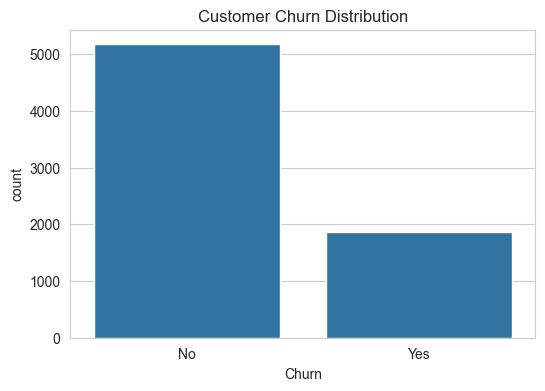

In [51]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.show()

# Churn Percentage

In [52]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

# Gender vs Churn

Do male and female customers churn differently?

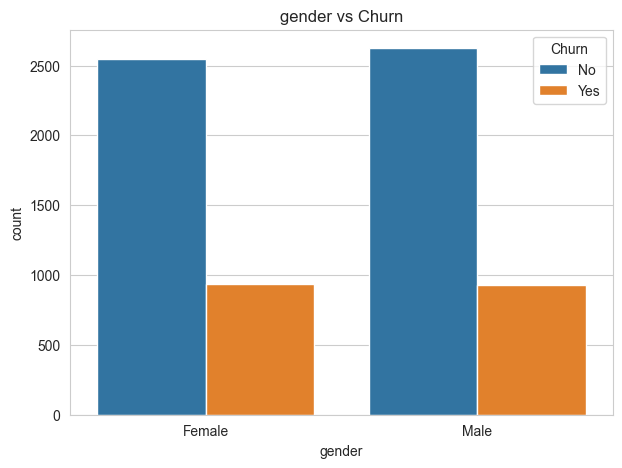

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("gender vs Churn")
plt.show()

# Contract vs Churn

Which contract type has the highest churn?

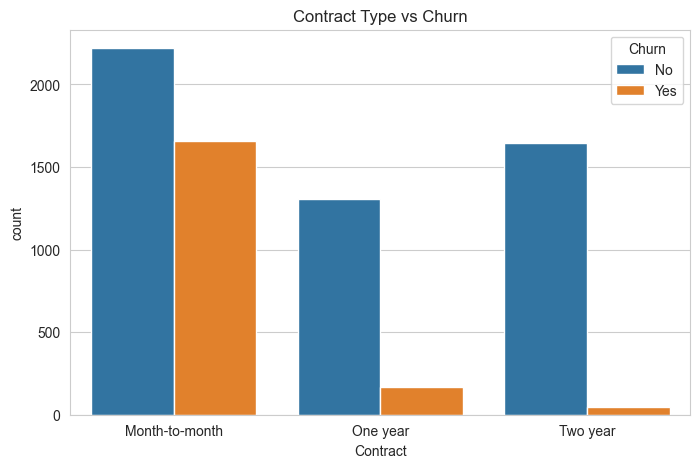

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")
plt.show()

# Monthly Charges Distribution

Are most customers paying low, medium, or high monthly charges?

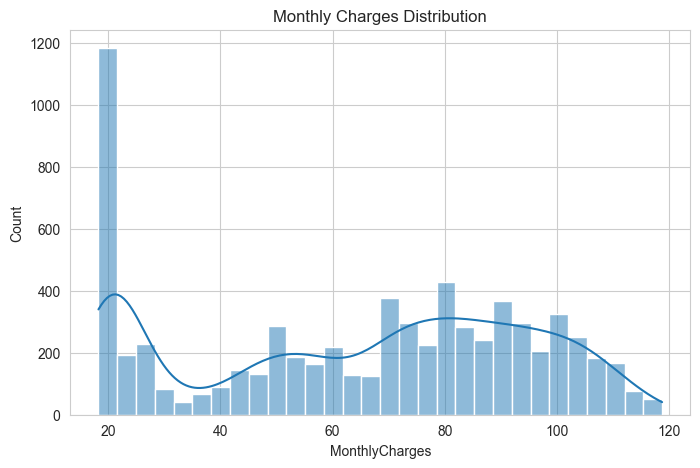

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.show()

# Monthly Charges vs Churn

Do customers with higher monthly bills tend to churn more?

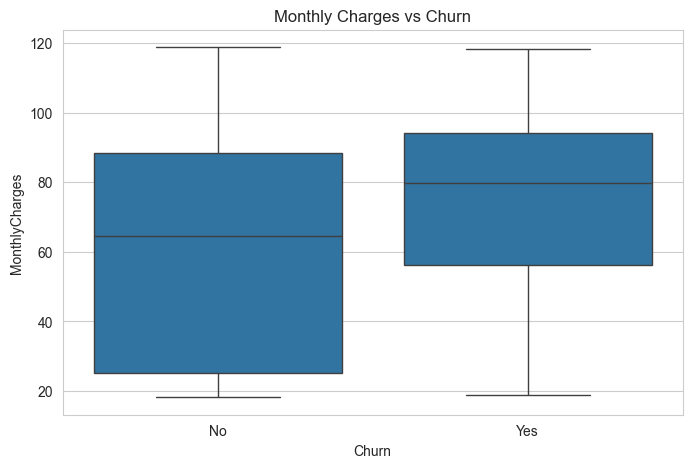

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

# Tenure vs Churn

Do customers who stay longer churn less?

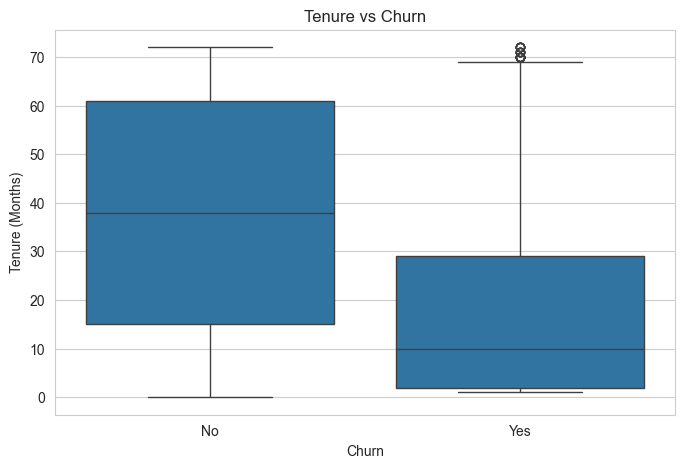

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

## Observation
 loyal customers stick around for a long time.
Customers who did churn have a median tenure of only around 10 months, with the IQR falling between roughly 2 and 29 months. The distribution is heavily skewed toward low tenure, and there are a few outliers around 70+ months (long-tenured customers who still churned, but they're rare exceptions).
The gap between the two medians (38 vs 10 months) is large — churned customers leave roughly 3-4x earlier than retained customers.

## Business Impact

 Retention efforts should be front-loaded — focus on onboarding and engagement in months 1–12, since that's when churn risk is highest. Tenure can also serve as a strong risk signal in your risk × value quadrant (low tenure + high charges = top priority for intervention).

# Internet Service vs Churn
 Which type of internet service has the highest churn?

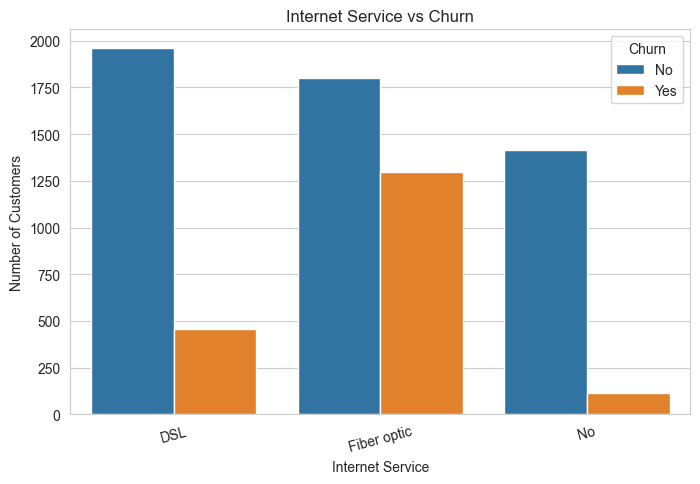

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

## Observation:
Customers using Fiber optic internet show a higher number of churn cases compared to DSL and customers with no internet service.

## Business Insight:
The company should investigate pricing, service quality, or customer satisfaction for Fiber optic users, as improving their experience could reduce churn.

# Payment Method vs Churn

Does the customer's payment method influence churn?

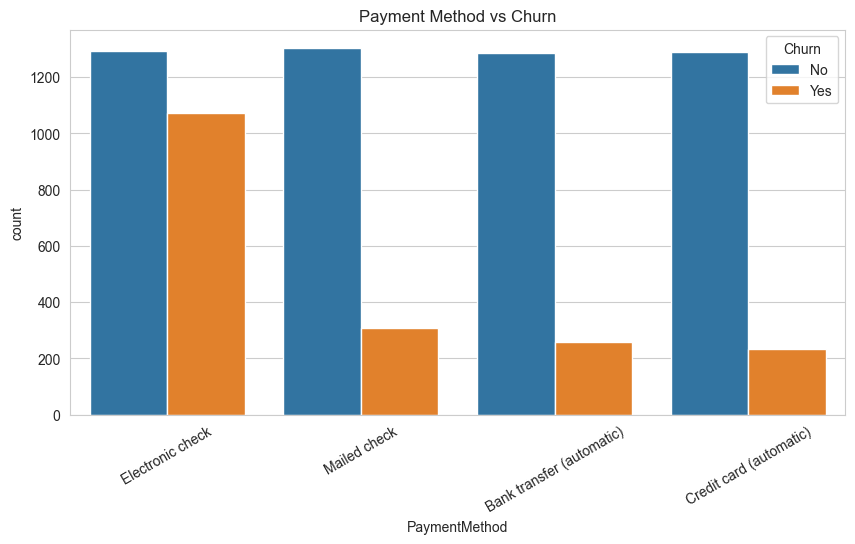

In [59]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Payment Method vs Churn")
plt.xticks(rotation=30)
plt.show()

## Observation
Customers using Electronic Check generally have higher churn.
Customers using automatic payment methods appear more likely to stay.
## Business Insight
Encourage customers to switch to automatic payment methods.
Automatic billing can improve customer convenience and reduce churn.

# Senior Citizen vs Churn

Are senior citizens more likely to churn than non-senior customers?

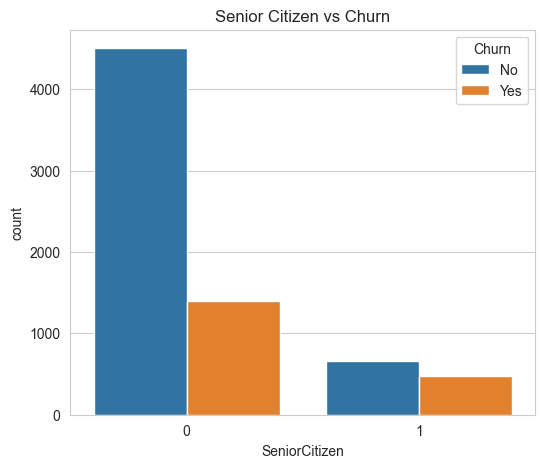

In [60]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Senior Citizen vs Churn")
plt.show()

## Observation
Senior citizens tend to have a higher proportion of churn compared to non-senior customers.
## Business Insight
Senior customers may benefit from dedicated support or simplified service plans.
Personalized retention campaigns could improve loyalty in this segment.

# Partner vs Churn

Does having a partner reduce the likelihood of churn?

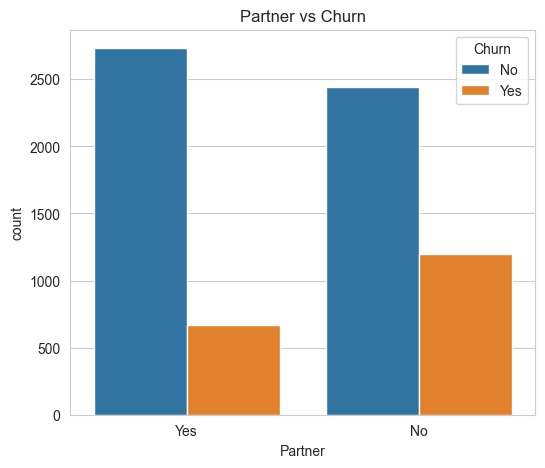

In [61]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Partner", hue="Churn")

plt.title("Partner vs Churn")
plt.show()

## Observation
Customers with partners are less likely to churn.
## Business Insight
Customers with stronger household commitments may be more stable.
Retention campaigns can focus more on customers without partners.

# Paperless Billing vs Churn

Is paperless billing associated with higher customer churn?

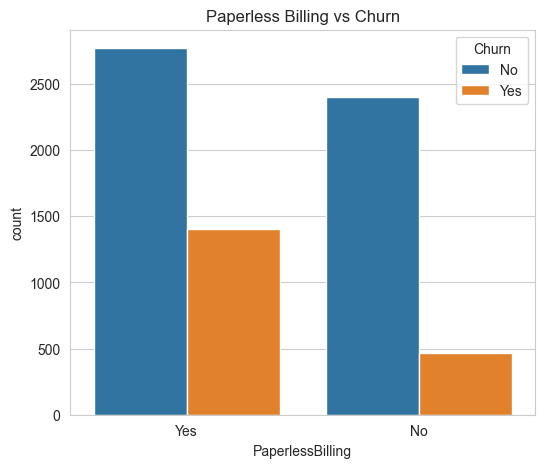

In [62]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="PaperlessBilling", hue="Churn")

plt.title("Paperless Billing vs Churn")
plt.show()

## Observation
Customers using paperless billing appear to churn more frequently.
## Business Insight
Since many paperless billing users are also month-to-month customers, investigate whether digital billing combined with flexible contracts contributes to higher churn.

# Correlation Heatmap

Which features have the strongest relationship with churn and with each other?

In [63]:
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_encoded.select_dtypes(include=["object","string"]).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

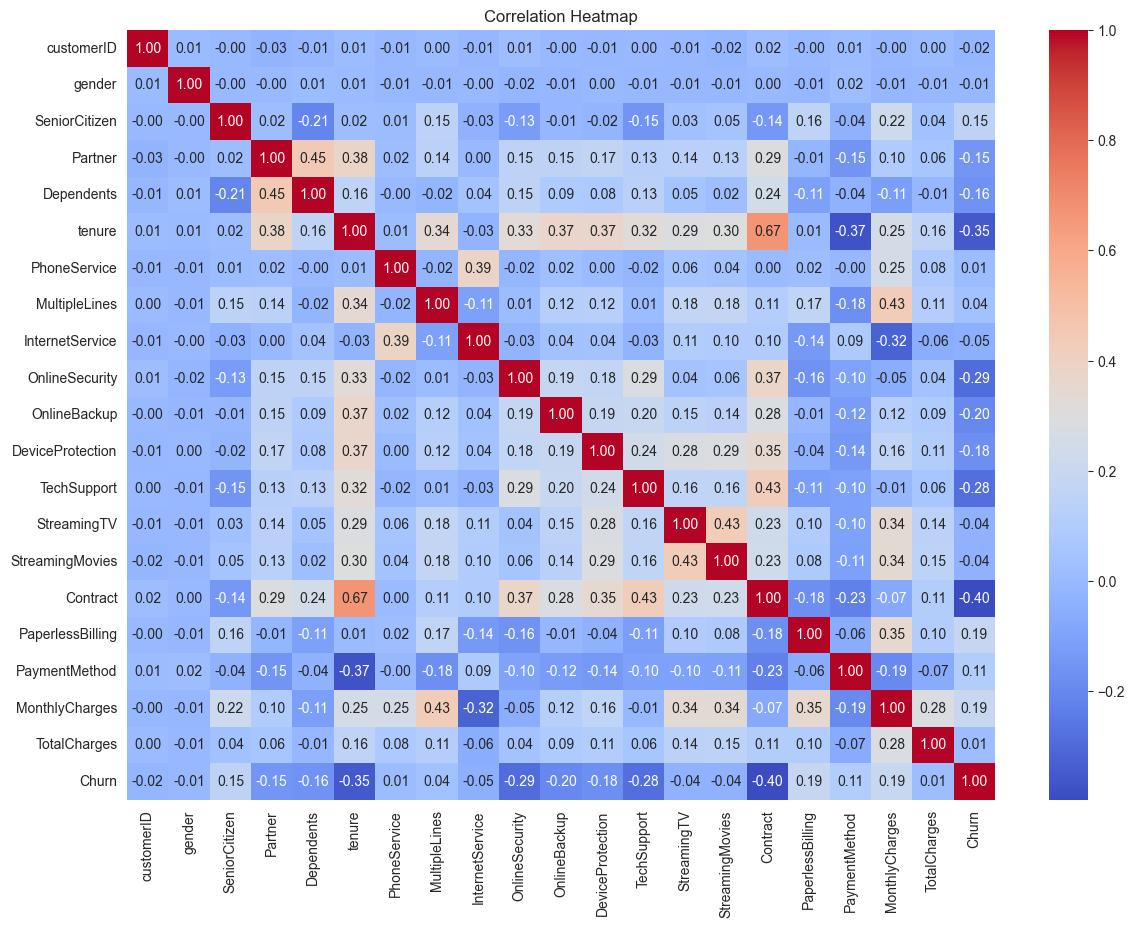

In [64]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Observation
Most features have weak to moderate correlations with each other.
Features such as Contract, Tenure, MonthlyCharges, and InternetService often show stronger relationships with Churn than demographic variables.
## Business Insight
Churn is driven by a combination of customer behavior and service characteristics rather than a single factor.
Multiple features should be used together in predictive models.

# **Final Business Summary**

# Key Findings
1.Customers on month-to-month contracts are the most likely to churn.

2.Customers with higher monthly charges tend to churn more frequently.

3.New customers (low tenure) are at greater risk of leaving.

4.Fiber optic customers show relatively higher churn, indicating potential issues with pricing or service quality.

5.Customers paying via Electronic Check churn more than those using automatic payment methods.

6.Customers with partners or dependents are generally more loyal.

7.Senior citizens have a higher churn tendency than non-senior customers.

8.Churn is influenced more by service usage and contract type than by basic demographic characteristics.

# What this means for the business
Based on the analysis, the telecom company should prioritize:

1.Converting month-to-month customers into longer-term contracts.

2.Offering personalized retention incentives to high-bill customers.

3.Improving the onboarding experience during the first few months of service.

4.Investigating the Fiber optic service experience to reduce dissatisfaction.

5.Encouraging customers to adopt automatic payment methods.

6.Desi6gning targeted retention campaigns for senior citizens and other high-risk customer segments.